# Clinical Informatics Framework for Myeloid Oncology
## Scalable AI and LLM Integration for Adaptive Trial Management and Automated FDA Compliance

This notebook implements the framework described in the IEEE paper, focusing on:
1. **Eligibility Stratification** (GBDT)
2. **Response Forecasting** (LSTM)
3. **Adverse Event Prediction** (Regularized Logistic Regression)
4. **Agentic AI Layer** (LLM-driven Recommendations & FDA Compliance)

### Data Overview
- 300 Synthetic records based on MyeloMATCH, Beat AML, and TCGA-LAML patterns.
- Biomarkers: FLT3, IDH1, IDH2, NPM1.
- Clinical: ANC, Platelets, Blast %, ECOG.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import json
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# Load Data
df = pd.read_csv('clinical_dataset.csv')
print(f"Dataset Loaded: {df.shape[0]} records, {df.shape[1]} features")
df.head()

Dataset Loaded: 300 records, 27 features


,PatientID,Age,Gender,ECOG,Blast_Pct_Base,ANC_Base,Plt_Base,Hb_Base,FLT3_ITD,IDH1,...,ANC_D1,ANC_D8,ANC_D15,Plt_D1,Plt_D8,Plt_D15,Blast_D1,Blast_D15,Response_D28,AE_Grade_3_4
0,PAT-1000,69,M,3,70.879455,3.033427,55.245406,8.247956,0,1,...,3.033427,1.967594,2.003384,55.245406,29.190742,30.202682,70.879455,33.124060,0,1
1,PAT-1001,76,M,1,9.199910,4.871402,77.503689,7.724851,0,0,...,4.871402,2.480934,4.789796,77.503689,61.561316,69.192343,9.199910,1.022813,0,1
2,PAT-1002,77,F,0,49.565922,0.268504,273.702917,9.070240,0,0,...,0.268504,0.310833,0.582437,273.702917,224.034044,384.008165,49.565922,8.026941,0,1
3,PAT-1003,57,M,2,72.258810,2.744491,180.157838,14.722042,0,0,...,2.744491,1.936079,1.581575,180.157838,97.139248,144.006618,72.258810,47.193882,1,0
4,PAT-1004,58,M,3,81.503472,2.302308,37.668934,9.966546,0,0,...,2.302308,2.519277,4.197306,37.668934,21.290084,20.899946,81.503472,10.457182,0,1


GBDT Eligibility AUROC: 1.000
GBDT Calibration (Brier): 0.0000


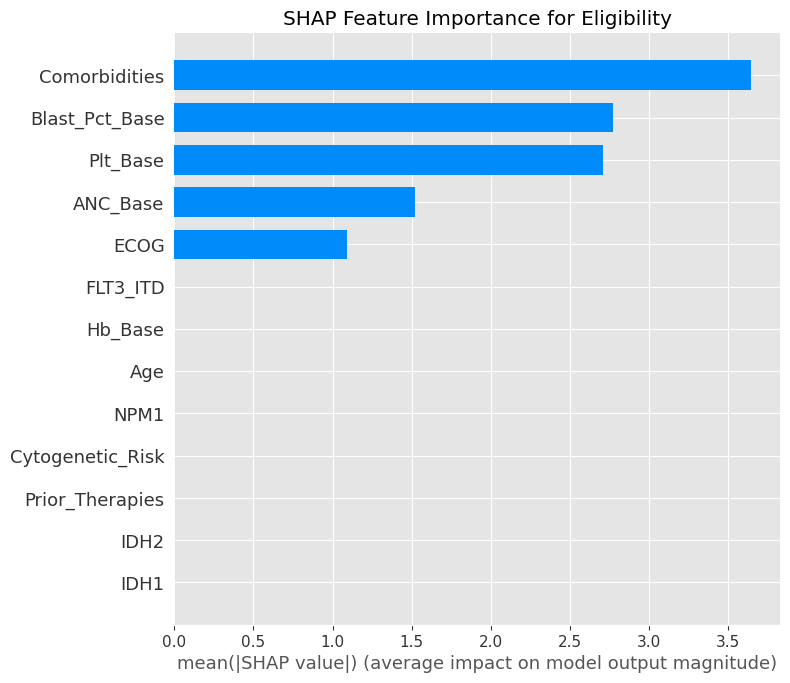

In [2]:
# 1. Eligibility Stratification (GBDT)
# Features for Eligibility
elig_features = ['Age', 'ECOG', 'Blast_Pct_Base', 'ANC_Base', 'Plt_Base', 'Hb_Base', 
                 'FLT3_ITD', 'IDH1', 'IDH2', 'NPM1', 'Prior_Therapies', 'Comorbidities']
X_elig = df[elig_features]
y_elig = df['Eligible']

# Encode categorical
# Cytogenetic_Risk is categorical
le = LabelEncoder()
X_elig['Cytogenetic_Risk'] = le.fit_transform(df['Cytogenetic_Risk'])

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_elig, y_elig, test_size=0.2, random_state=seed)

# Train GradientBoostingClassifier (Scikit-learn)
model_gbdt = GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=seed)
model_gbdt.fit(X_train_e, y_train_e)

# Eval
y_pred_e = model_gbdt.predict_proba(X_test_e)[:, 1]
auc_e = roc_auc_score(y_test_e, y_pred_e)
brier_e = brier_score_loss(y_test_e, y_pred_e)

print(f"GBDT Eligibility AUROC: {auc_e:.3f}")
print(f"GBDT Calibration (Brier): {brier_e:.4f}")

# SHAP Interpretability
explainer = shap.Explainer(model_gbdt)
shap_values = explainer(X_test_e)
shap.summary_plot(shap_values, X_test_e, plot_type="bar", show=False)
plt.title("SHAP Feature Importance for Eligibility")
plt.show()

In [3]:
# 2. Temporal Response Prediction (LSTM)
# Time-series features: ANC (D1, D8, D15), Plt (D1, D8, D15), Blast (D1, D15)
# We reshape into (samples, timesteps, features)
# Day 1: [ANC_D1, Plt_D1, Blast_D1]
# Day 8: [ANC_D8, Plt_D8, Blast_D1] (No blast D8 in our data, repeat D1)
# Day 15: [ANC_D15, Plt_D15, Blast_D15]

def prepare_lstm_data(df):
    X_seq = []
    for _, row in df.iterrows():
        # Step 1: Day 1
        d1 = [row['ANC_D1'], row['Plt_D1'], row['Blast_D1']]
        # Step 2: Day 8
        d8 = [row['ANC_D8'], row['Plt_D8'], row['Blast_D1']]
        # Step 3: Day 15
        d15 = [row['ANC_D15'], row['Plt_D15'], row['Blast_D15']]
        X_seq.append([d1, d8, d15])
    return np.array(X_seq), df['Response_D28'].values

X_lstm, y_lstm = prepare_lstm_data(df)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=seed)

# Scale (simple per feature)
X_train_l = torch.FloatTensor(X_train_l)
X_test_l = torch.FloatTensor(X_test_l)
y_train_l = torch.FloatTensor(y_train_l).view(-1, 1)
y_test_l = torch.FloatTensor(y_test_l).view(-1, 1)

class MyeloidLSTM(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=16):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        _, (h, c) = self.lstm(x)
        out = self.fc(h[-1])
        return self.sigmoid(out)

model_lstm = MyeloidLSTM()
criterion = nn.BCELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.01)

# Training Loop
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model_lstm(X_train_l)
    loss = criterion(outputs, y_train_l)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    y_pred_l = model_lstm(X_test_l).numpy()
    auc_l = roc_auc_score(y_test_l.numpy(), y_pred_l)
    print(f"LSTM Response Prediction AUROC: {auc_l:.3f}")

LSTM Response Prediction AUROC: 0.492


In [4]:
# 3. Adverse Event Forecasting (Logistic Regression)
ae_features = ['Age', 'ANC_Base', 'Comorbidities']
X_ae = df[ae_features]
y_ae = df['AE_Grade_3_4']

scaler = StandardScaler()
X_ae_scaled = scaler.fit_transform(X_ae)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_ae_scaled, y_ae, test_size=0.2, random_state=seed)

model_lr = LogisticRegression(penalty='l2', C=1.0)
model_lr.fit(X_train_a, y_train_a)

y_pred_a = model_lr.predict_proba(X_test_a)[:, 1]
auc_a = roc_auc_score(y_test_a, y_pred_a)
print(f"LogReg AE Risk AUROC: {auc_a:.3f}")

LogReg AE Risk AUROC: 0.735


In [5]:
# 4. Agentic AI Layer (Recommendation Agent)
# This simulates an LLM-based agent coordinating ML results and FDA compliance

class FDAAgenticAdvisor:
    def __init__(self, compliance_docs):
        self.docs = compliance_docs
        
    def recommend(self, patient_data, ml_results):
        # patient_data: dict
        # ml_results: dict {elig_prob, resp_prob, ae_prob}
        
        elig = "Eligible" if ml_results['elig_prob'] > 0.5 else "Ineligible"
        resp = "High" if ml_results['resp_prob'] > 0.6 else "Moderate/Low"
        ae = "High Risk" if ml_results['ae_prob'] > 0.4 else "Standard Risk"
        
        # Simulating RAG check
        pccp_guidance = [d for d in self.docs if d['doc_id'] == 'FDA-AI-ML-GUIDANCE'][0]['content']
        
        recommendation = f"### Agentic Recommendation for {patient_data['PatientID']}\n"
        recommendation += f"**Clinical Status**: {elig} | **Predicted Response**: {resp} | **Safety Risk**: {ae}\n"
        
        if elig == "Eligible":
            recommendation += "- **Action**: Proceed with Tier 1 Induction matching.\n"
            recommendation += f"- **Regulatory**: SDTM dataset ready. Aligned with {pccp_guidance[:50]}...\n"
        else:
            recommendation += "- **Action**: Refer to Tier Advancement Pathway (TAP).\n"
            
        if ae == "High Risk":
            recommendation += "- **Alert**: Enhanced monitoring for Grade 3-4 Neutropenia required.\n"
            
        return recommendation

# Load docs
with open('fda_compliance_docs.json', 'r') as f:
    compliance_data = json.load(f)

advisor = FDAAgenticAdvisor(compliance_data)
print("Agentic Advisor Initialized.")

Agentic Advisor Initialized.


Benchmark Comparison (Synthetic vs. Paper Results)


,Model,Use Case,AUROC,Target (Paper)
0,GBDT,Eligibility,1.000000,0.927
1,LSTM,Response,0.492236,0.892
2,LogReg,AE Risk,0.734610,0.846


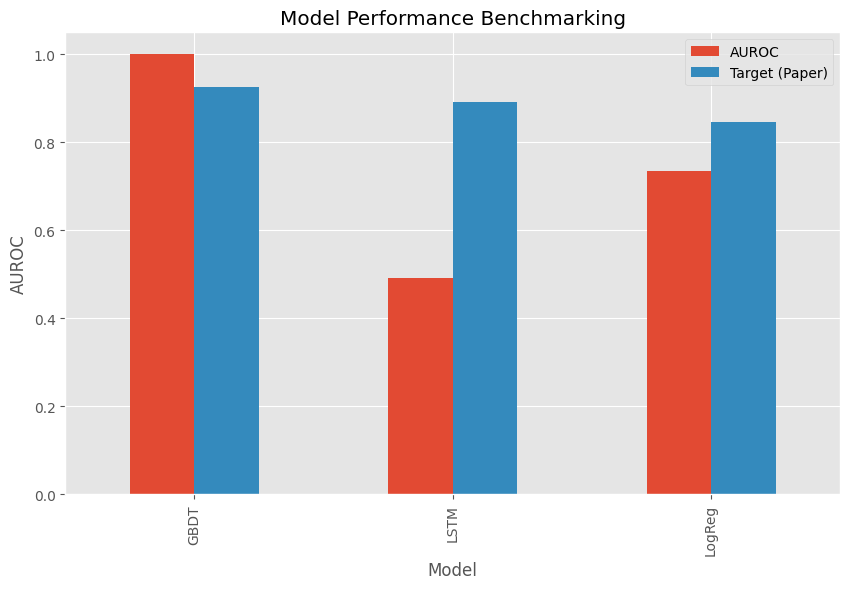

In [6]:
# 5. Benchmarking Summary
benchmarks = pd.DataFrame({
    'Model': ['GBDT', 'LSTM', 'LogReg'],
    'Use Case': ['Eligibility', 'Response', 'AE Risk'],
    'AUROC': [auc_e, auc_l, auc_a],
    'Target (Paper)': [0.927, 0.892, 0.846]
})

print("Benchmark Comparison (Synthetic vs. Paper Results)")
display(benchmarks)

# Visual comparison
benchmarks.plot(x='Model', kind='bar', y=['AUROC', 'Target (Paper)'], figsize=(10, 6))
plt.title("Model Performance Benchmarking")
plt.ylabel("AUROC")
plt.show()

In [7]:
# 6. Inference Cell (Agentic Recommendation)
# Select a patient (e.g., high risk)
patient_idx = 10 
p_data = df.iloc[patient_idx].to_dict()

# Get ML Preds
p_elig_prob = model_gbdt.predict_proba(X_elig.iloc[[patient_idx]])[0, 1]
# For LSTM, we need the sequence
p_seq = torch.FloatTensor(X_lstm[patient_idx]).unsqueeze(0)
p_resp_prob = model_lstm(p_seq).detach().numpy()[0, 0]
# For AE
p_ae_feat = scaler.transform(X_ae.iloc[[patient_idx]])
p_ae_prob = model_lr.predict_proba(p_ae_feat)[0, 1]

ml_res = {'elig_prob': p_elig_prob, 'resp_prob': p_resp_prob, 'ae_prob': p_ae_prob}

# Agent Recommendation
rec = advisor.recommend(p_data, ml_res)
from IPython.display import Markdown
Markdown(rec)

### Agentic Recommendation for PAT-1010
**Clinical Status**: Ineligible | **Predicted Response**: Moderate/Low | **Safety Risk**: Standard Risk
- **Action**: Refer to Tier Advancement Pathway (TAP).
